<p align="center" style="font-size:24px;"><b>HW 5 - Decision Trees and the LASSO and Boosting for Regression</b></p>


## 1. Decision Trees as Interpretable Models

Import packages

In [32]:
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, message=".*Downcasting behavior in `replace`.*")

### (a) Obtain Data

Get the Accute Inamations Data Set

In [33]:
root = "../data/acute+inflammations/"
data_file = "diagnosis.data"

df = pd.read_csv(root+data_file, sep='\t', header=None, encoding='utf-16')

df.columns = [
    "temperature",
    "nausea",
    "lumbar_pain",
    "urine_pushing",
    "micturition_pains",
    "burning_urethra",
    "bladder_inflammation",
    "nephritis"
]

df["temperature"] = df["temperature"].str.replace(',', '.').astype(float)
df = df.replace({'yes': 1, 'no': 0})

df

,temperature,nausea,lumbar_pain,urine_pushing,micturition_pains,burning_urethra,bladder_inflammation,nephritis
0,35.5,0,1,0,0,0,0,0
1,35.9,0,0,1,1,1,1,0
2,35.9,0,1,0,0,0,0,0
3,36.0,0,0,1,1,1,1,0
4,36.0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
115,41.4,0,1,1,0,1,0,1
116,41.5,0,0,0,0,0,0,0
117,41.5,1,1,0,1,0,0,1
118,41.5,0,1,1,0,1,0,1


### (b) Build a decision tree

In [34]:
df["illness_class"] = (df["bladder_inflammation"].astype(str) + df["nephritis"].astype(str))
illness_mapping = {"00": 0, "01": 1, "10": 2, "11": 3}
df["illness_class"] = df["illness_class"].map(illness_mapping)

df.head()

,temperature,nausea,lumbar_pain,urine_pushing,micturition_pains,burning_urethra,bladder_inflammation,nephritis,illness_class
0,35.5,0,1,0,0,0,0,0,0
1,35.9,0,0,1,1,1,1,0,2
2,35.9,0,1,0,0,0,0,0,0
3,36.0,0,0,1,1,1,1,0,2
4,36.0,0,1,0,0,0,0,0,0


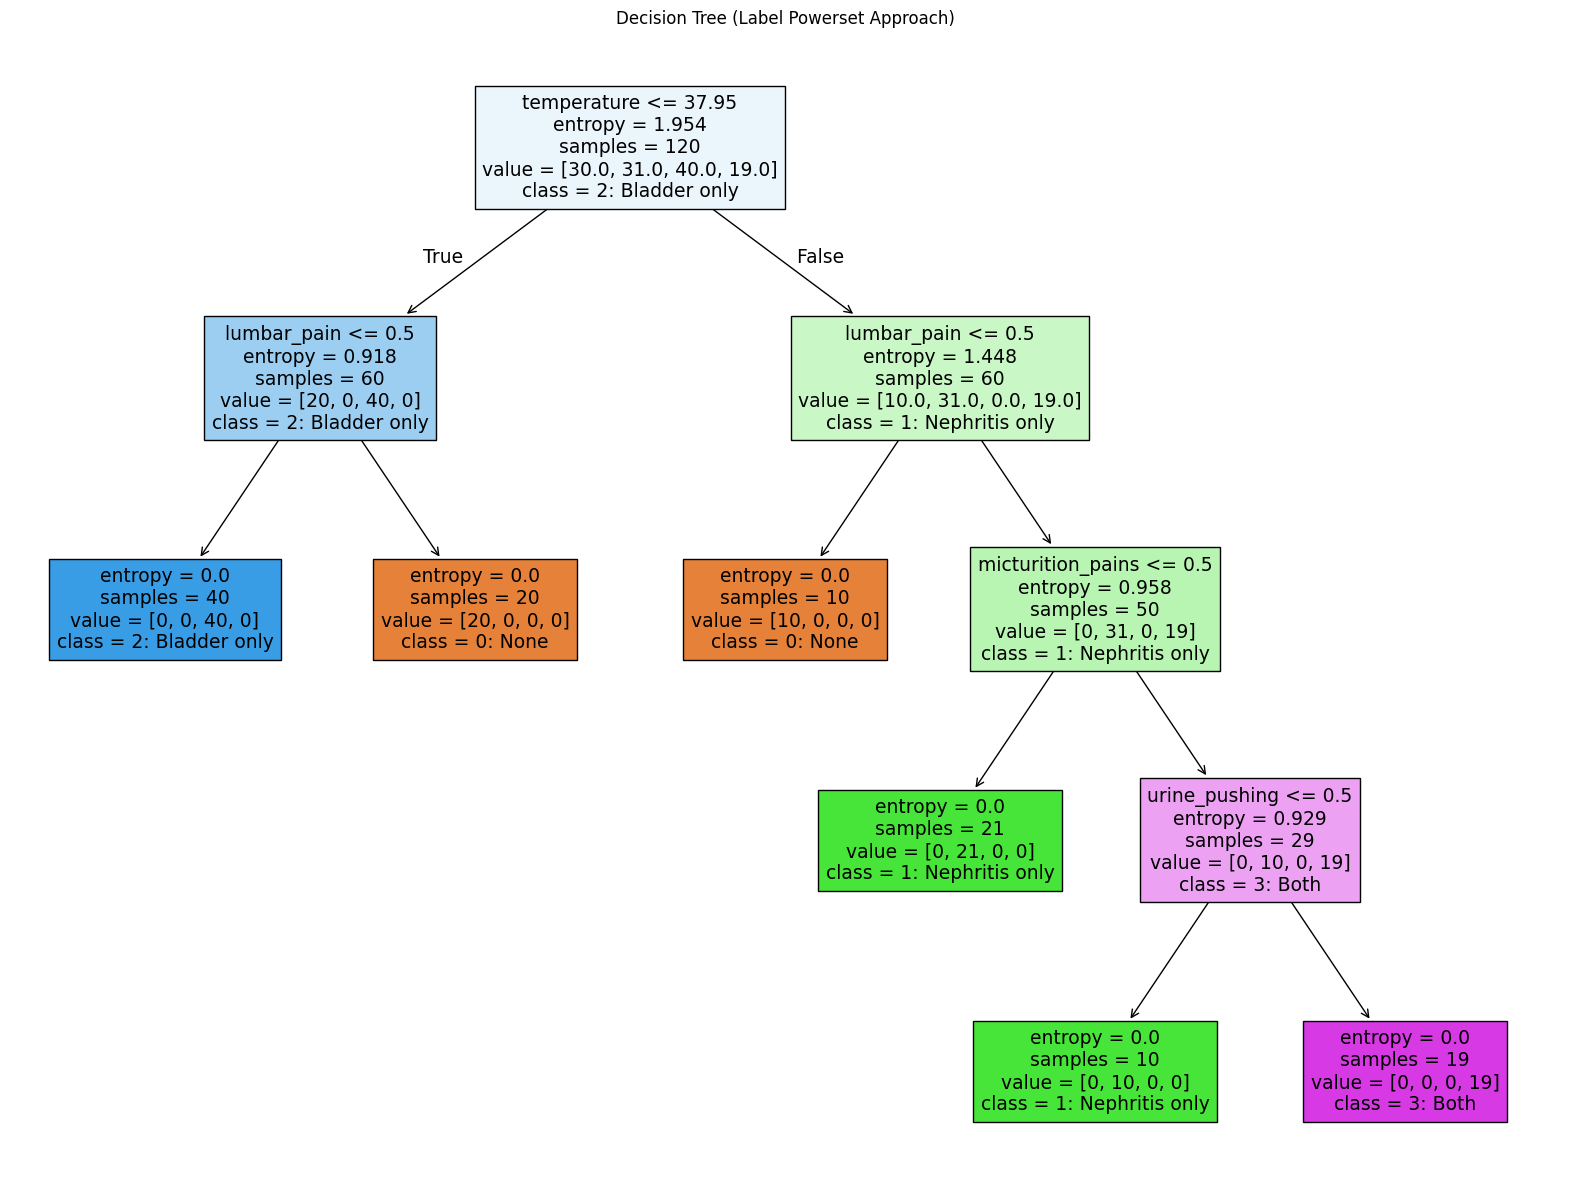

In [35]:
X = df[["temperature", "nausea", "lumbar_pain", "urine_pushing", "micturition_pains", "burning_urethra"]]
y = df["illness_class"]

lp_model = DecisionTreeClassifier(criterion="entropy")
lp_model.fit(X, y)

plt.figure(figsize=(20,15))
plot_tree(
    lp_model,
    feature_names=X.columns,
    class_names=[
        "0: None", 
        "1: Nephritis only", 
        "2: Bladder only", 
        "3: Both"
    ],
    filled=True
)
plt.title("Decision Tree (Label Powerset Approach)")
plt.show()

### (c) Convert the decision rules

In [36]:
illness_map = {0: "None", 1: "Nephritis only", 2: "Bladder only", 3: "Both"}

def tree_to_code(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    print("def tree({}):".format(", ".join(feature_names)))

    def recurse(node, depth):
        indent = "  " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            print(f"{indent}if {name} <= {threshold:.2f}:")
            recurse(tree_.children_left[node], depth + 1)
            print(f"{indent}else:  # if {name} > {threshold:.2f}")
            recurse(tree_.children_right[node], depth + 1)
        else:
            class_idx = tree_.value[node].argmax()
            print(f"{indent}return {class_idx}  # {illness_map[class_idx]}")

    recurse(0, 1)


In [37]:
tree_to_code(lp_model, X.columns)

def tree(temperature, nausea, lumbar_pain, urine_pushing, micturition_pains, burning_urethra):
  if temperature <= 37.95:
    if lumbar_pain <= 0.50:
      return 2  # Bladder only
    else:  # if lumbar_pain > 0.50
      return 0  # None
  else:  # if temperature > 37.95
    if lumbar_pain <= 0.50:
      return 0  # None
    else:  # if lumbar_pain > 0.50
      if micturition_pains <= 0.50:
        return 1  # Nephritis only
      else:  # if micturition_pains > 0.50
        if urine_pushing <= 0.50:
          return 1  # Nephritis only
        else:  # if urine_pushing > 0.50
          return 3  # Both


### (d) Prune the tree

In [38]:
path = lp_model.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas

alpha_scores = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=11, ccp_alpha=alpha)
    scores = cross_val_score(clf, X, y, cv=5)
    alpha_scores.append(np.mean(scores))

alpha_table = pd.DataFrame({
    "alpha": ccp_alphas,
    "cv_accuracy": alpha_scores
})

alpha_table["alpha"] = alpha_table["alpha"].round(4)
alpha_table["cv_accuracy"] = alpha_table["cv_accuracy"].round(4)

alpha_table = alpha_table.sort_values(by="cv_accuracy", ascending=False).reset_index(drop=True)

alpha_table



,alpha,cv_accuracy
0,0.0000,0.9583
1,0.1996,0.5917
2,0.3250,0.3333
3,0.4591,0.3333
4,0.7704,0.3333


After cross-validation, we can tell the best alpha which has the highest accuracy is 0. That means, to obtain the best accuracy, we should not prune the tree. And with higher alpha value, the tree will be simplier but the accuracy will be lower.

To prune the tree, we choose alpha = 0.1, which is close to 0 to maintain the level of accuracy and to obtain a minimal decision tree.

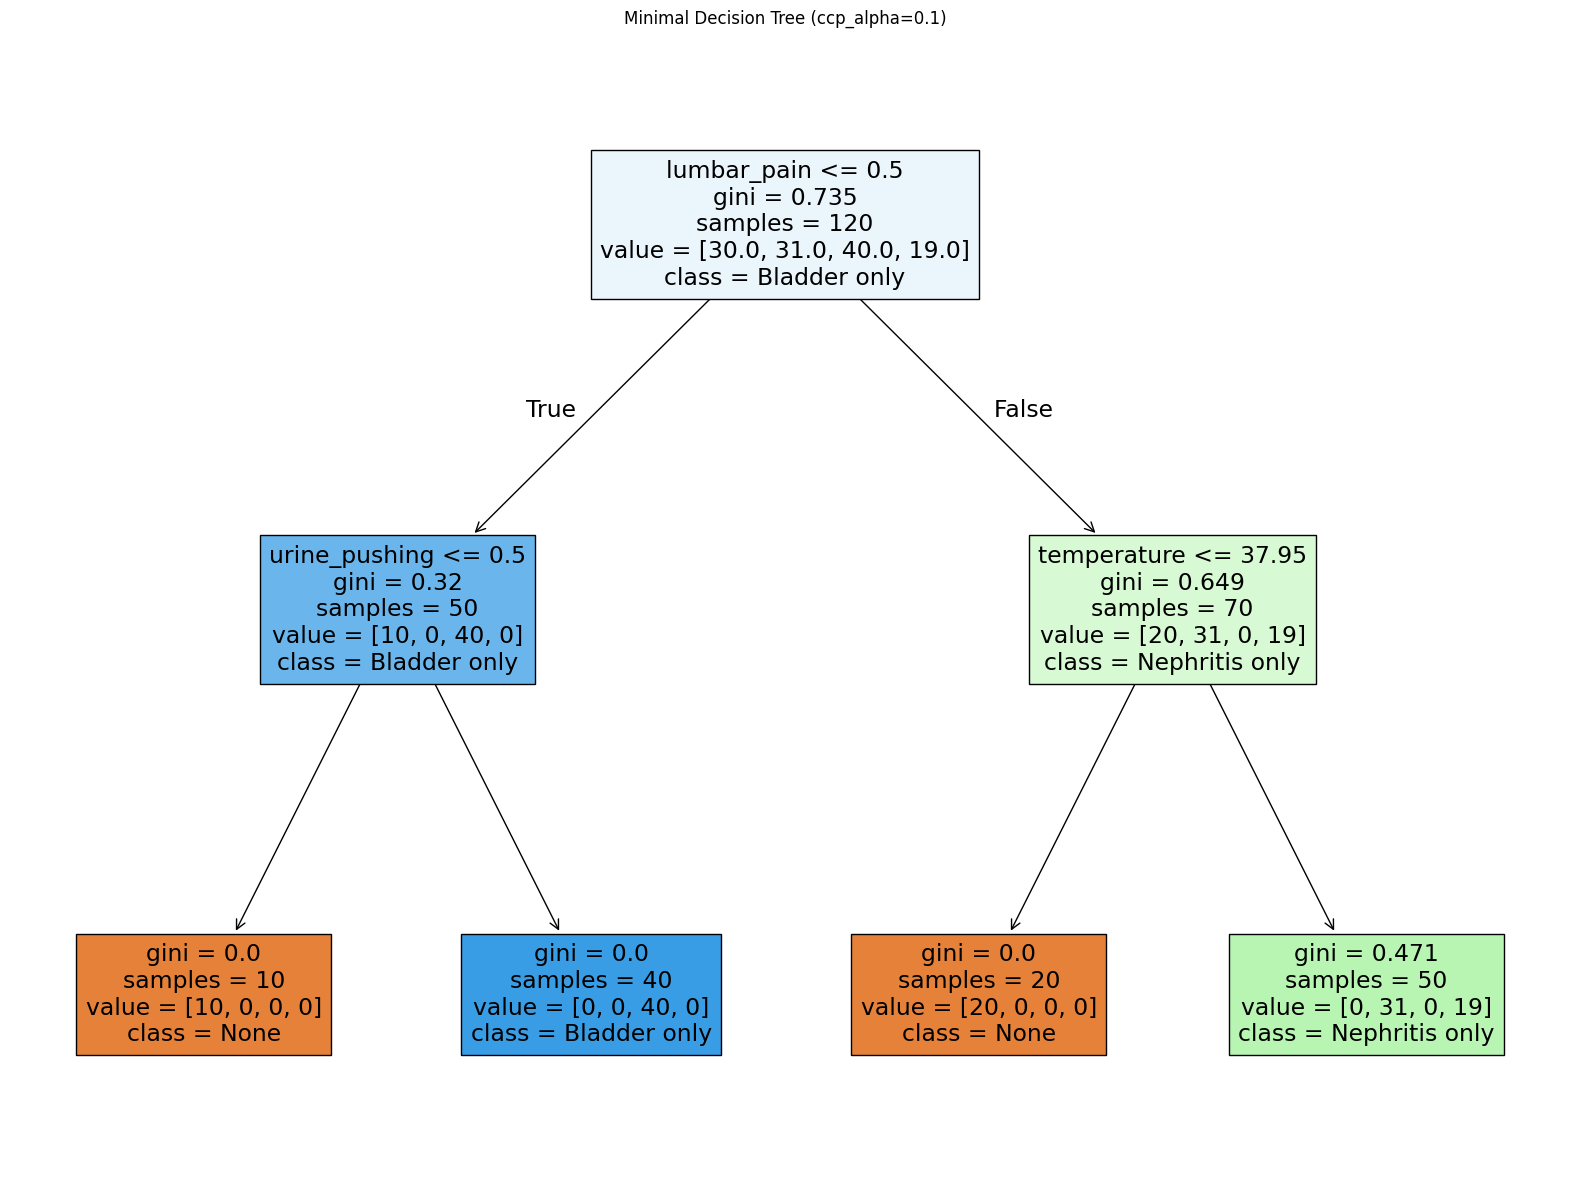

In [39]:
alpha_manual = 0.1
pruned_model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_manual)
pruned_model.fit(X, y)

plt.figure(figsize=(20,15))
plot_tree(
    pruned_model,
    feature_names=X.columns,
    class_names=["None", "Nephritis only", "Bladder only", "Both"],
    filled=True
)
plt.title(f"Minimal Decision Tree (ccp_alpha={alpha_manual})")
plt.show()

In [40]:
tree_to_code(pruned_model, X.columns)

def tree(temperature, nausea, lumbar_pain, urine_pushing, micturition_pains, burning_urethra):
  if lumbar_pain <= 0.50:
    if urine_pushing <= 0.50:
      return 0  # None
    else:  # if urine_pushing > 0.50
      return 2  # Bladder only
  else:  # if lumbar_pain > 0.50
    if temperature <= 37.95:
      return 0  # None
    else:  # if temperature > 37.95
      return 1  # Nephritis only


After pruning the tree, the depth and the number of leaves of the tree becomes lower. And there are fewer levels of nested ifs in the IF-THEN rules.

## 2. The LASSO and Boosting for Regression

### (a) Obtain Data

In [41]:
cc_root = "../data/communities+and+crime/"
cc_file = "communities.data"

df = pd.read_csv(cc_root+cc_file, header=None, na_values="?")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03


In [42]:
train_size = 1495
train_df = df.iloc[:train_size, :].copy()
test_df  = df.iloc[train_size:, :].copy()
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1495, 128)
Test shape: (499, 128)


### (b) Missing values

In [43]:
nonpredictive_cols = [0, 1, 2, 3, 4]        # state, county, community, communityname, fold
target_col = df.columns[-1]         # ViolentCrimesPerPop
feature_cols = [c for c in df.columns if c not in nonpredictive_cols + [target_col]]

train_size = 1495
X_train_raw = df.loc[:train_size-1, feature_cols].apply(pd.to_numeric, errors='coerce')
X_test_raw  = df.loc[train_size:, feature_cols].apply(pd.to_numeric, errors='coerce')
y_train_raw = pd.to_numeric(df.loc[:train_size-1, target_col], errors='coerce')
y_test_raw  = pd.to_numeric(df.loc[train_size:, target_col], errors='coerce')

imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train_raw),
                       columns=X_train_raw.columns,
                       index=X_train_raw.index)
X_test = pd.DataFrame(imputer.transform(X_test_raw),
                      columns=X_train_raw.columns,
                      index=X_test_raw.index)

y_train = y_train_raw.fillna(y_train_raw.mean())
y_test = y_test_raw.fillna(y_train_raw.mean())  # use training mean to avoid leakage

print("Sample X_train data:")
X_train.head()

Sample X_train data:


,5,6,7,8,9,10,11,12,13,14,...,117,118,119,120,121,122,123,124,125,126
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.290000,0.12,0.26,0.20,0.060000,0.040000,0.900000,0.500000,0.32,0.140000
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.323598,0.02,0.12,0.45,0.163975,0.080502,0.713054,0.451883,0.00,0.190753
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.323598,0.01,0.21,0.02,0.163975,0.080502,0.713054,0.451883,0.00,0.190753
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.323598,0.02,0.39,0.28,0.163975,0.080502,0.713054,0.451883,0.00,0.190753
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.323598,0.04,0.09,0.02,0.163975,0.080502,0.713054,0.451883,0.00,0.190753


### (c) Plot a correlation matrix

Correlation matrix shape: (122, 122)


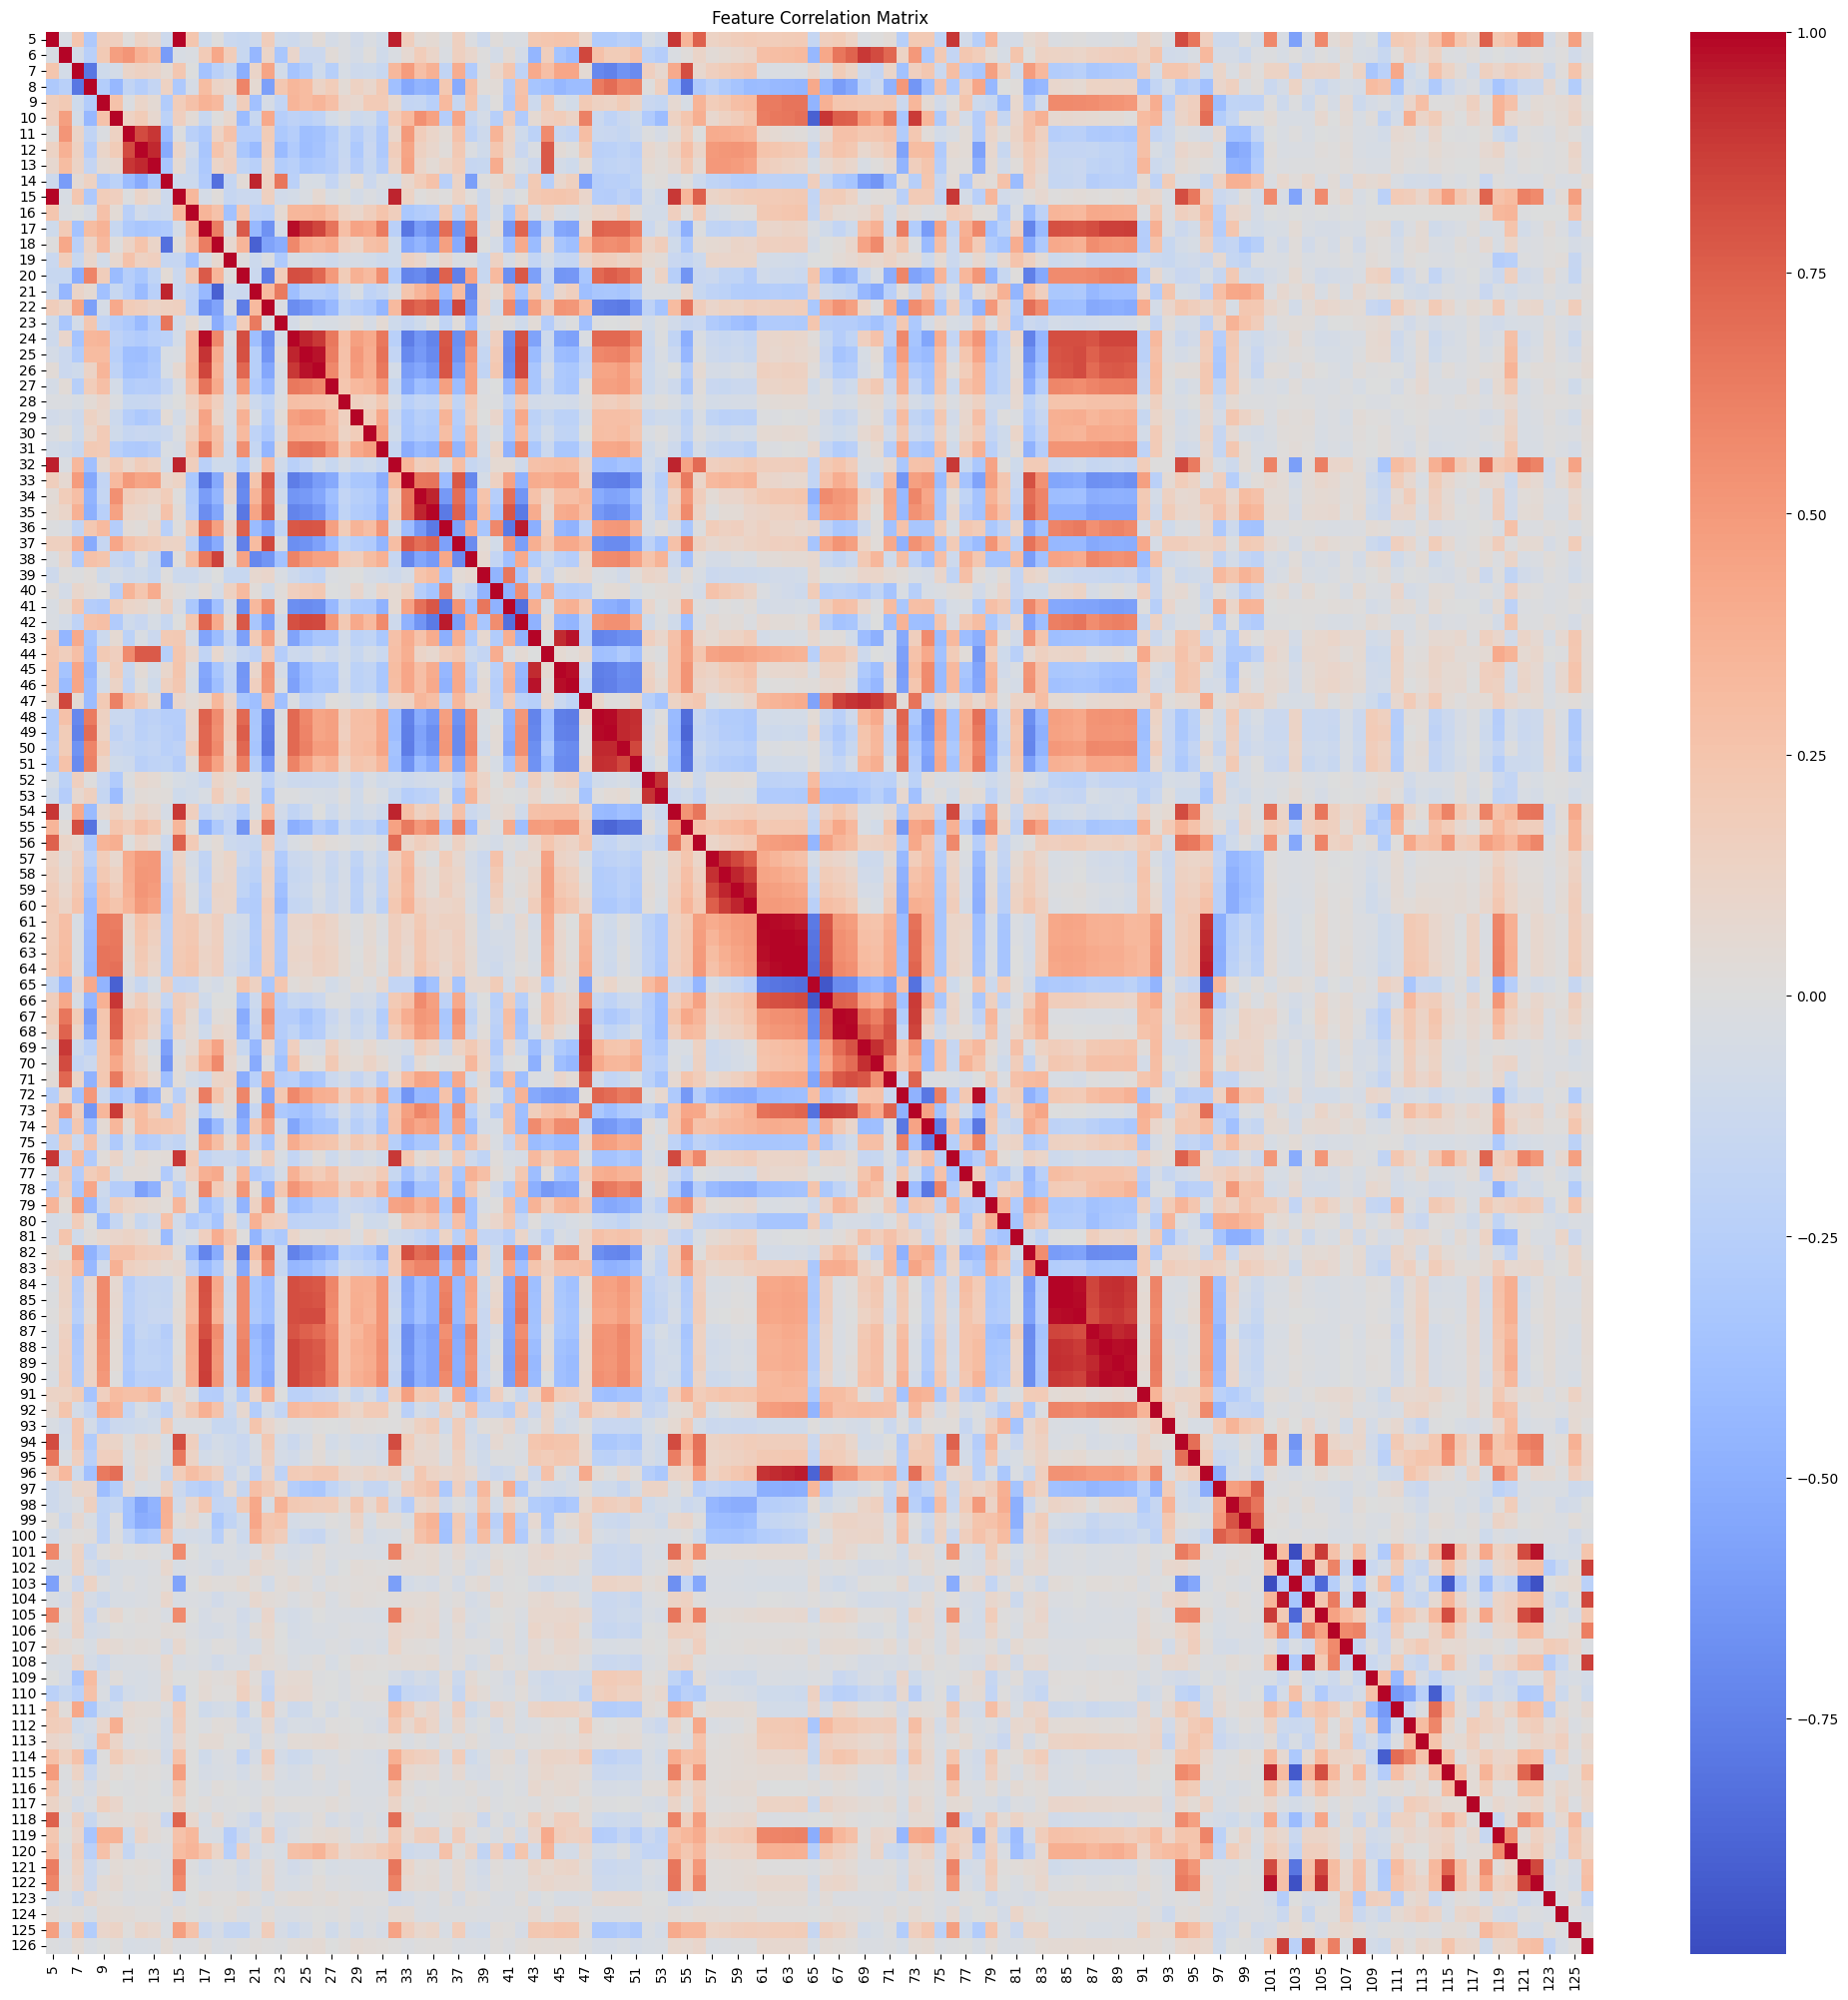

In [44]:
corr_matrix = X_train.corr()

print("Correlation matrix shape:", corr_matrix.shape)

plt.figure(figsize=(25, 25))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

### (d) Calculate the Coefficient of Variation CV

In [45]:
feature_means = X_train.mean()
feature_stds  = X_train.std()

cv_values = feature_stds / feature_means

cv_df = pd.DataFrame({
    "Feature_index": X_train.columns,
    "Mean": feature_means.values,
    "Std": feature_stds.values,
    "CV": cv_values.values
})

cv_df_sorted = cv_df.sort_values(by="CV", ascending=False)

cv_df_sorted.head(15)

,Feature_index,Mean,Std,CV
90,95,0.022983,0.098665,4.292923
89,94,0.029599,0.102736,3.470952
49,54,0.037204,0.113806,3.058964
51,56,0.030595,0.089541,2.926635
120,125,0.093304,0.238201,2.552946
27,32,0.056849,0.133167,2.342443
0,5,0.058167,0.130359,2.241105
10,15,0.064649,0.131784,2.038461
71,76,0.076475,0.150538,1.968467
113,118,0.064107,0.105482,1.645408


### (e) Scatter plots and box plots for highest CV features

Scatterplot - Top 11 Features vs Each Other:


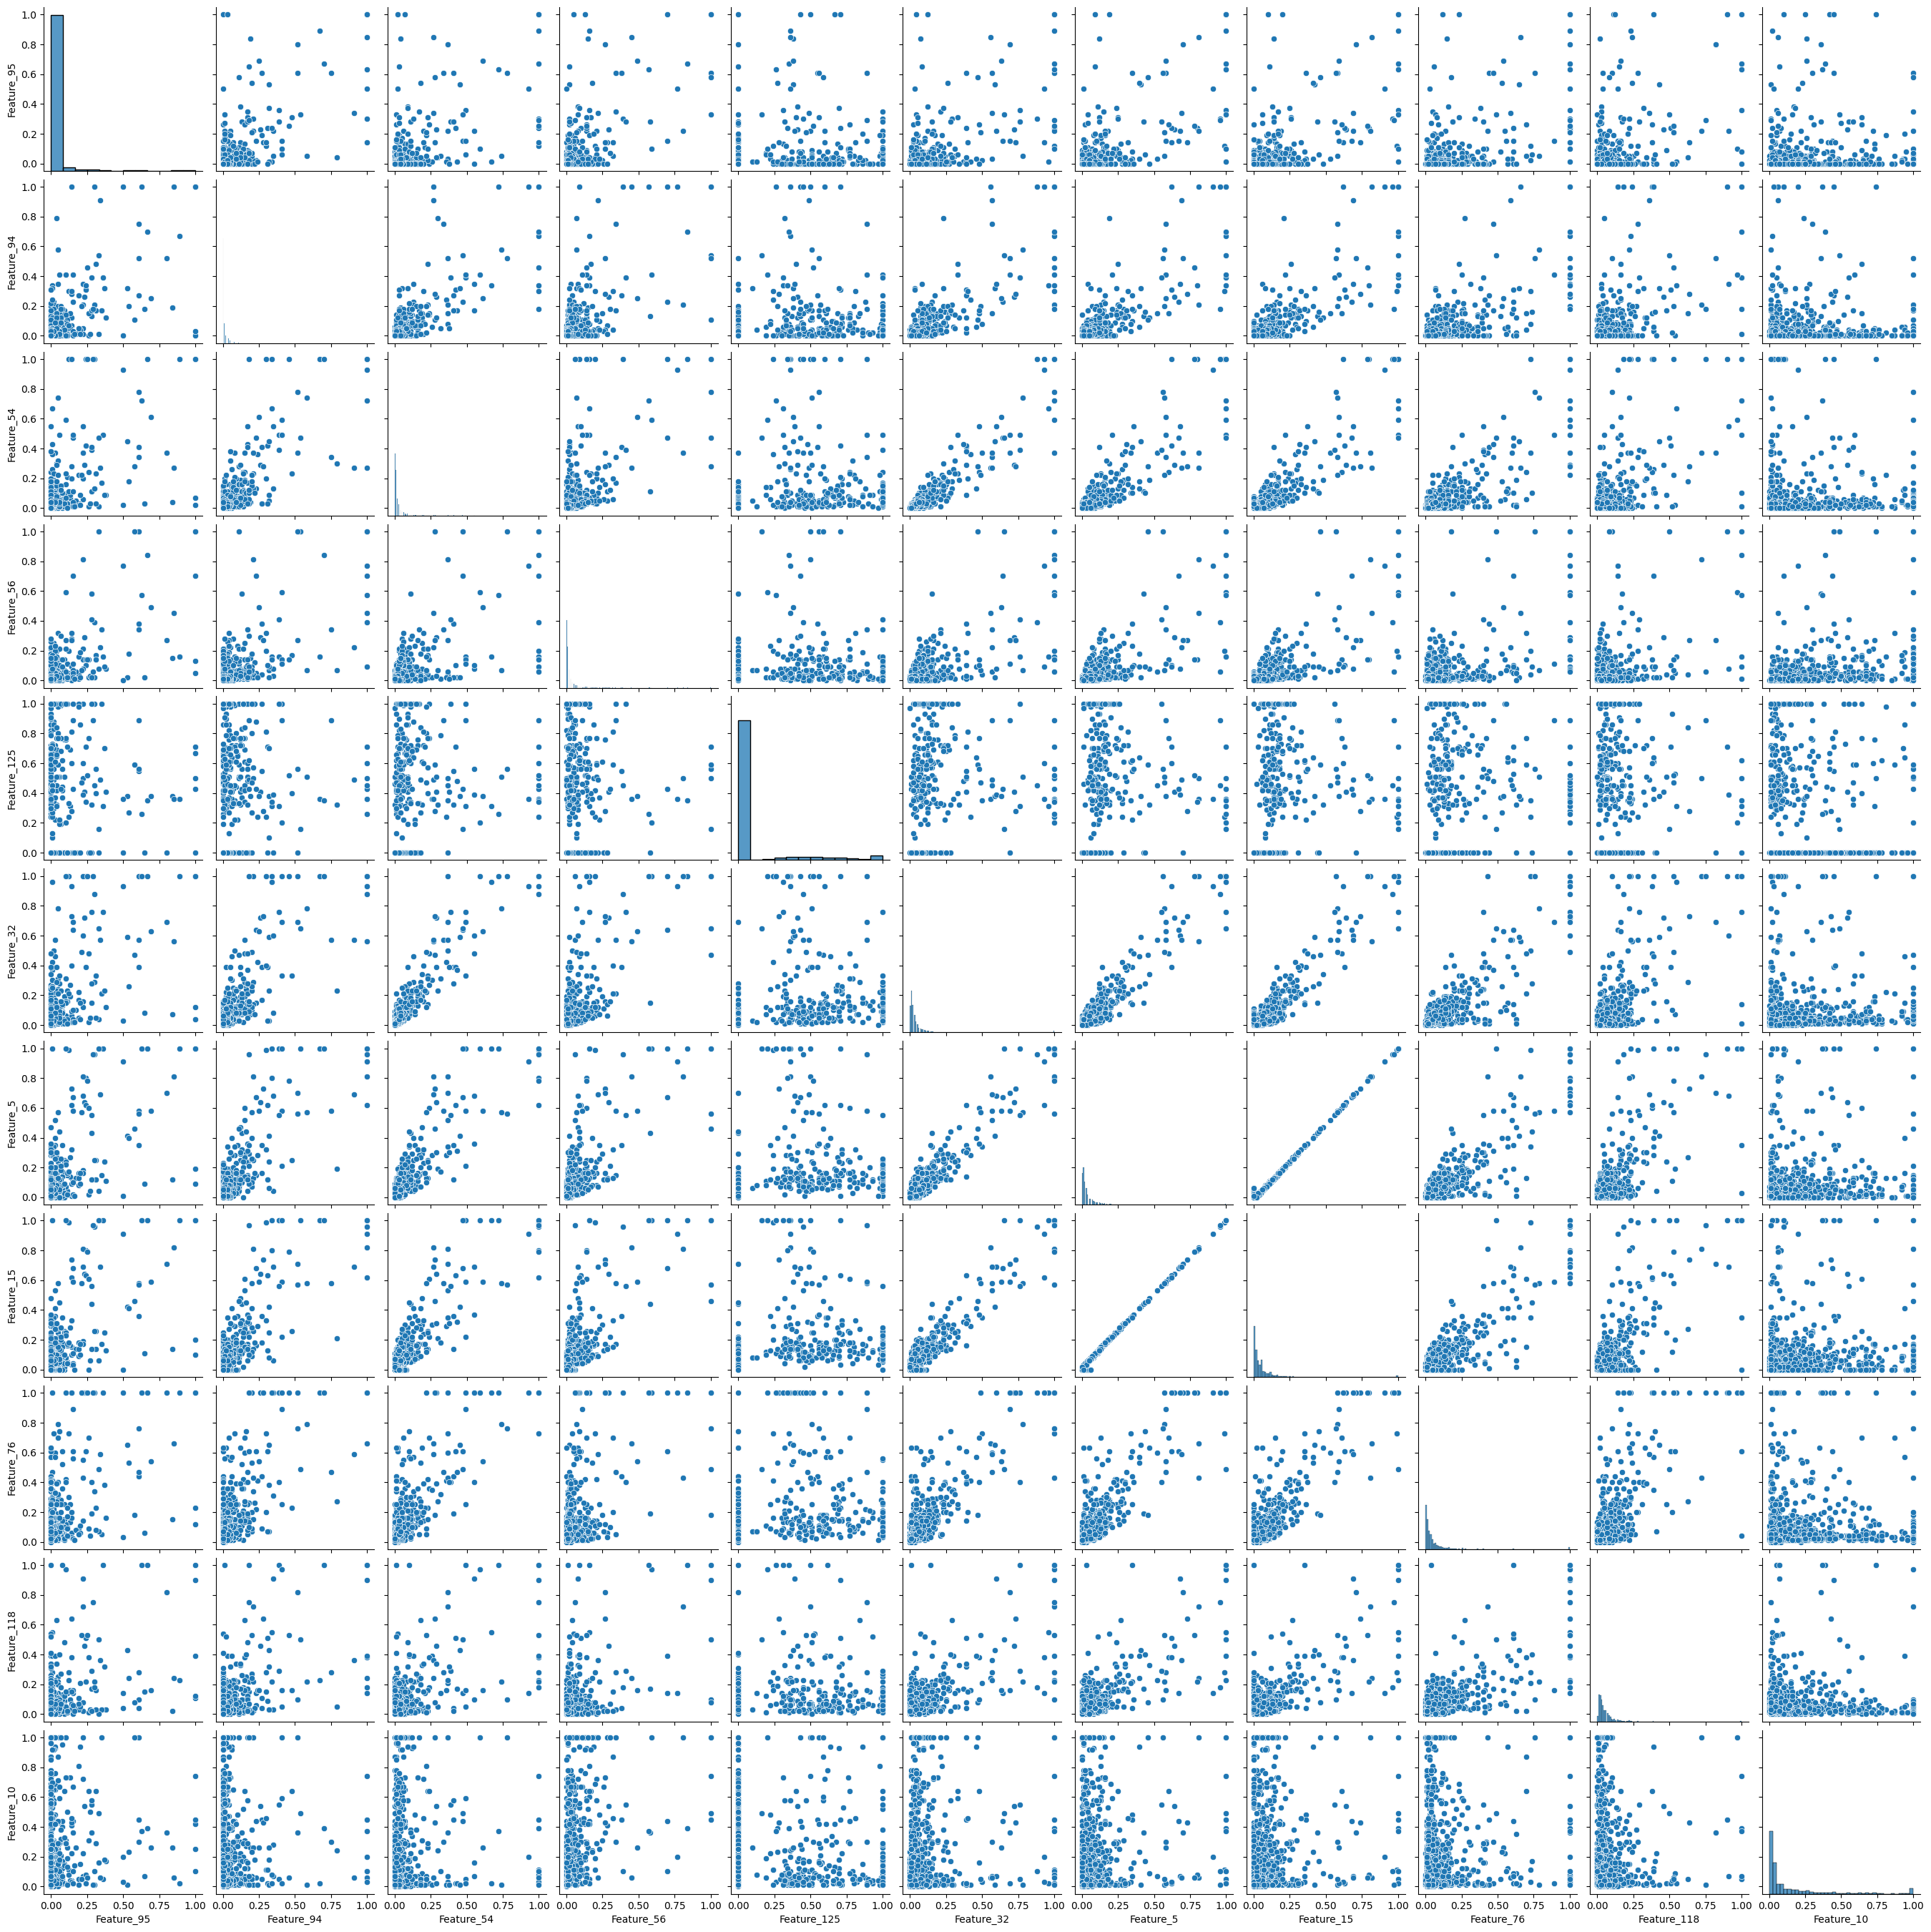

In [46]:
top_k = int(math.sqrt(128))
top_features = cv_df_sorted.head(top_k)["Feature_index"].values

top_feature_df = X_train[top_features]
top_feature_df.columns = [f"Feature_{i}" for i in top_features]

sns.pairplot(top_feature_df, kind="scatter")
print("Scatterplot - Top 11 Features vs Each Other:")

plt.show()

Scatter Plots - Top 11 Features vs Target (ViolentCrimesPerPop):


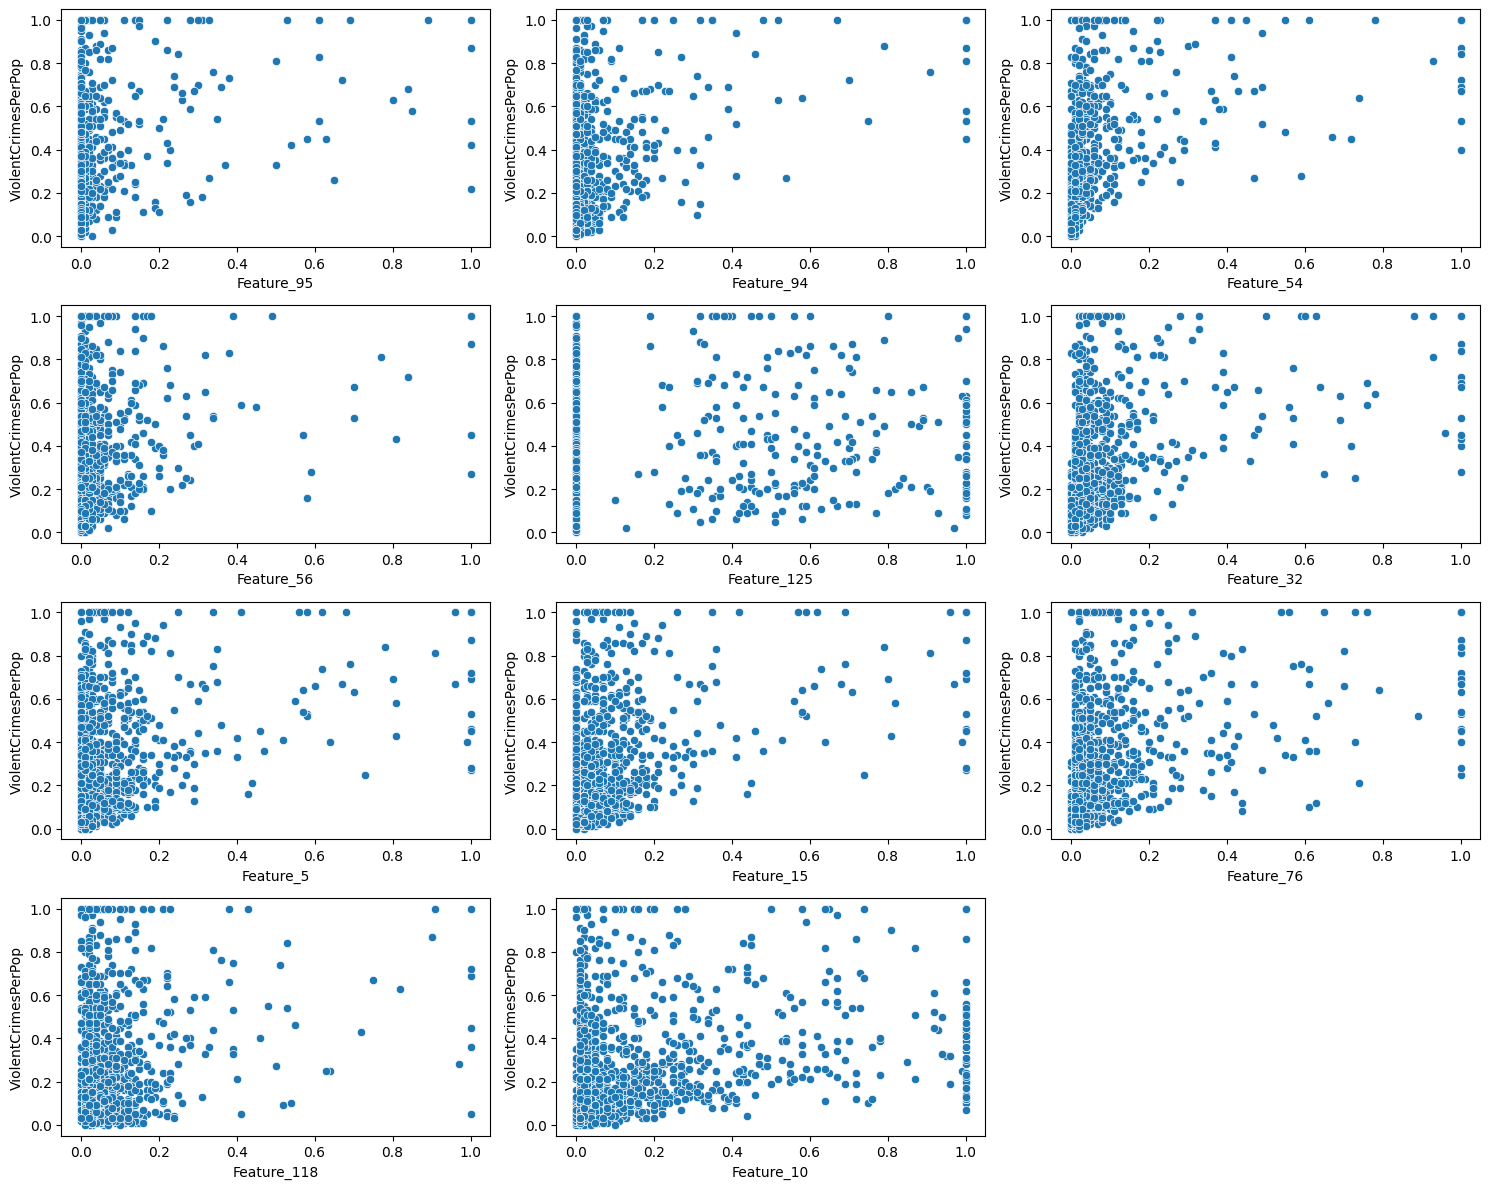

In [47]:
feature_target_df = top_feature_df.copy()
feature_target_df["ViolentCrimesPerPop"] = y_train.values

features = [f"Feature_{i}" for i in top_features]

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(
        data=feature_target_df, 
        x=feature, y="ViolentCrimesPerPop", 
        ax=axes[i]
    )

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

print("Scatter Plots - Top 11 Features vs Target (ViolentCrimesPerPop):")
plt.tight_layout()
plt.show()

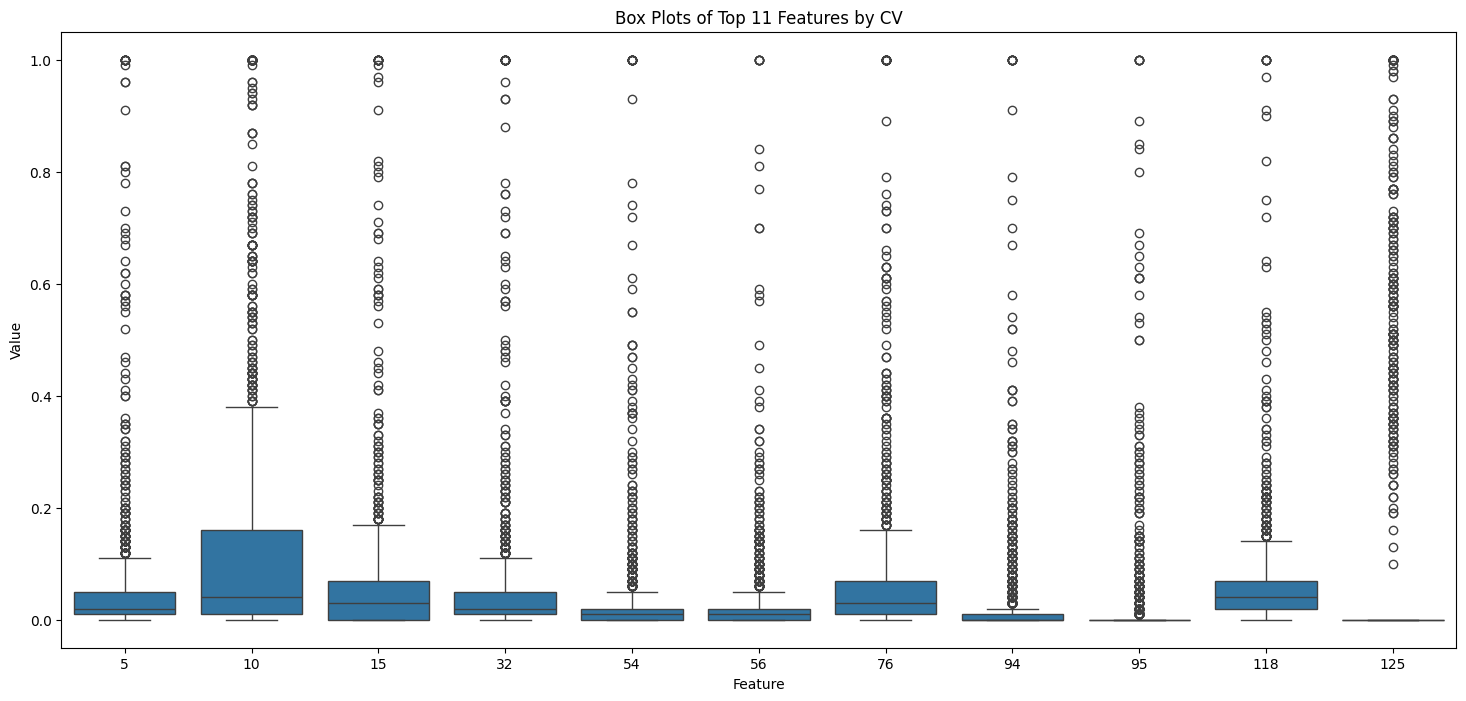

In [48]:
df_box = X_train[top_features].melt(var_name="Feature", value_name="Value")

plt.figure(figsize=(18, 8))
sns.boxplot(x="Feature", y="Value", data=df_box)
plt.title("Box Plots of Top 11 Features by CV")
plt.show()

From the feature-feature scatterplot, we can see several features are correlated. This tells us there may be overlapping information between these features. From the feature-target scatterplot, we can tell the relationship between features and the target are mostly non-linear. These scatterplots help us to understand the magnitude of relationship amoung features or between features and the target. But we cannot conclude any information about the significance of the features. We have to fit model and test, and do cross-validations amount models to obtain such conclusions.

### (f) Fit a linear model

In [49]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Linear Regression Test Result")
print(f"    MSE : {mse:.4f}")
print(f"    MAE : {mae:.4f}")
print(f"    R^2 : {r2:.4f}")

Linear Regression Test Result
    MSE : 0.0181
    MAE : 0.0966
    R^2 : 0.6185


### (g) Fit a ridge regression model

In [50]:
alphas = np.logspace(-6, 3, 100)

ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train, y_train)

y_pred = ridge_model.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("Ridge Regression Test Result")
print(f"    Best alpha: {ridge_model.alpha_:.4f}")
print(f"    MSE : {mse:.4f}")
print(f"    MAE : {mae:.4f}")
print(f"    R^2 : {r2:.4f}")

Ridge Regression Test Result
    Best alpha: 2.3101
    MSE : 0.0176
    MAE : 0.0946
    R^2 : 0.6299


### (h) Fit a LASSO model

In [51]:
y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()

alphas = np.logspace(-6, 3, 100)

lasso_model = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000)
lasso_model.fit(X_train, y_tr)

y_pred = lasso_model.predict(X_test)

mse  = mean_squared_error(y_te, y_pred)
mae  = mean_absolute_error(y_te, y_pred)
r2   = r2_score(y_te, y_pred)

coef = pd.Series(lasso_model.coef_, index=X_train.columns)
selected_feats = coef[coef != 0].index.tolist()

print("LASSO (no additional standardization)")
print(f"    Best alpha : {lasso_model.alpha_:.4f}")
print(f"    MSE   : {mse:.4f}")
print(f"    MAE   : {mae:.4f}")
print(f"    R^2   : {r2:.4f}")
print("Selected features:", selected_feats)
print(f"Number of selected features: {len(selected_feats)}")

LASSO (no additional standardization)
    Best alpha : 0.0001
    MSE   : 0.0177
    MAE   : 0.0947
    R^2   : 0.6270
Selected features: [7, 9, 11, 12, 16, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 33, 34, 38, 39, 41, 43, 44, 45, 49, 50, 51, 53, 54, 55, 56, 57, 60, 64, 66, 68, 69, 72, 73, 74, 75, 76, 77, 79, 80, 81, 82, 83, 84, 87, 90, 91, 92, 93, 94, 95, 96, 97, 99, 104, 105, 107, 109, 111, 113, 116, 117, 118, 119, 120, 123, 124, 125, 126]
Number of selected features: 75


| Index (after drop) | Original Index | Feature Name |
|--------------------:|----------------:|--------------------------|
| 7  | 12  | agePct12t29 |
| 9  | 14  | agePct65up |
| 11 | 16  | pctUrban |
| 12 | 17  | medIncome |
| 16 | 21  | pctWPubAsst |
| 18 | 23  | pctWRetire |
| 19 | 24  | medFamInc |
| 20 | 25  | perCapInc |
| 21 | 26  | whitePerCap |
| 22 | 27  | blackPerCap |
| 23 | 28  | indianPerCap |
| 26 | 31  | HispPerCap |
| 27 | 32  | NumUnderPov |
| 28 | 33  | PctPopUnderPov |
| 29 | 34  | PctLess9thGrade |
| 30 | 35  | PctNotHSGrad |
| 31 | 36  | PctBSorMore |
| 33 | 38  | PctEmploy |
| 34 | 39  | PctEmplManu |
| 38 | 43  | MalePctDivorce |
| 39 | 44  | MalePctNevMarr |
| 41 | 46  | TotalPctDiv |
| 43 | 48  | PctFam2Par |
| 44 | 49  | PctKids2Par |
| 45 | 50  | PctYoungKids2Par |
| 49 | 54  | PctWorkMom |
| 50 | 55  | NumIlleg |
| 51 | 56  | PctIlleg |
| 53 | 58  | PctImmigRecent |
| 54 | 59  | PctImmigRec5 |
| 55 | 60  | PctImmigRec8 |
| 56 | 61  | PctImmigRec10 |
| 57 | 62  | PctRecentImmig |
| 60 | 65  | PctSpeakEnglOnly |
| 64 | 69  | PctLargHouseOccup |
| 66 | 71  | PersPerOccupHous |
| 68 | 73  | PctPersOwnOccup |
| 69 | 74  | PctPersDenseHous |
| 72 | 77  | MedYrHousBuilt |
| 73 | 78  | PctHousNoPhone |
| 74 | 79  | PctWOFullPlumb |
| 75 | 80  | OwnOccLowQuart |
| 76 | 81  | OwnOccMedVal |
| 77 | 82  | OwnOccHiQuart |
| 79 | 84  | RentMedian |
| 80 | 85  | RentHighQ |
| 81 | 86  | MedRent |
| 82 | 87  | MedRentPctHousInc |
| 83 | 88  | MedOwnCostPctInc |
| 84 | 89  | MedOwnCostPctIncNoMtg |
| 87 | 92  | PctForeignBorn |
| 90 | 95  | PctSameHouse85 |
| 91 | 96  | PctSameCity85 |
| 92 | 97  | PctSameState85 |
| 93 | 98  | LemasSwornFT |
| 94 | 99  | LemasSwFTPerPop |
| 95 | 100 | LemasSwFTFieldOps |
| 96 | 101 | LemasSwFTFieldPerPop |
| 97 | 102 | LemasTotalReq |
| 99 | 104 | PolicReqPerOffic |
| 104| 109 | PctPolicWhite |
| 105| 110 | PctPolicBlack |
| 107| 112 | PctPolicAsian |
| 109| 114 | OfficAssgnDrugUnits |
| 111| 116 | PolicAveOTWorked |
| 113| 118 | PopDens |
| 116| 121 | PolicCars |
| 117| 122 | PolicOperBudg |
| 118| 123 | LemasPctPolicOnPatr |
| 119| 124 | LemasGangUnitDeploy |
| 120| 125 | LemasPctOfficDrugUn |
| 123| 128 | ViolentCrimesPerPop |
| 124| — | (invalid) |
| 125| — | (invalid) |
| 126| — | (invalid) |


We are selecting 72 features in this model. At the end of the list, there are 3 indices out of the range because the index shifting caused by deleting first 5 non-predictive features. We will ignore these 3 indices and keep the rest of features fitting the model. 

In [52]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()

alphas = np.logspace(-6, 3, 100)

lasso_std = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=20000)
lasso_std.fit(X_train_std, y_tr)

y_pred_std = lasso_std.predict(X_test_std)
mse_std  = mean_squared_error(y_te, y_pred_std)
mae_std  = mean_absolute_error(y_te, y_pred_std)
r2_std   = r2_score(y_te, y_pred_std)

coef_std = pd.Series(lasso_std.coef_, index=X_train.columns)
selected_feats_std = coef_std[coef_std != 0].index.tolist()

print("LASSO (with standardized features)")
print(f"    Best alpha : {lasso_std.alpha_:.4f}")
print(f"    MSE   : {mse_std:.4f}")
print(f"    MAE   : {mae_std:.4f}")
print(f"    R^2   : {r2_std:.4f}")
print("Selected features:", selected_feats_std)
print(f"Number of selected features: {len(selected_feats_std)}")

LASSO (with standardized features)
    Best alpha : 0.0008
    MSE   : 0.0178
    MAE   : 0.0948
    R^2   : 0.6259
Selected features: [7, 9, 11, 12, 16, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 33, 34, 38, 39, 43, 44, 45, 49, 50, 51, 53, 54, 55, 56, 58, 60, 64, 66, 68, 69, 72, 73, 74, 76, 77, 79, 80, 81, 82, 83, 87, 90, 91, 92, 93, 94, 95, 96, 99, 104, 105, 107, 109, 110, 111, 112, 113, 115, 116, 117, 118, 119, 120, 121, 123, 124]
Number of selected features: 73


| Index (after drop) | Original Index | Feature Name |
|--------------------:|----------------:|-------------------------------|
| 7  | 12  | agePct12t29 |
| 9  | 14  | agePct65up |
| 11 | 16  | pctUrban |
| 12 | 17  | medIncome |
| 16 | 21  | pctWPubAsst |
| 18 | 23  | pctWRetire |
| 19 | 24  | medFamInc |
| 20 | 25  | perCapInc |
| 21 | 26  | whitePerCap |
| 22 | 27  | blackPerCap |
| 23 | 28  | indianPerCap |
| 26 | 31  | HispPerCap |
| 27 | 32  | NumUnderPov |
| 28 | 33  | PctPopUnderPov |
| 29 | 34  | PctLess9thGrade |
| 30 | 35  | PctNotHSGrad |
| 31 | 36  | PctBSorMore |
| 33 | 38  | PctEmploy |
| 34 | 39  | PctEmplManu |
| 38 | 43  | MalePctDivorce |
| 39 | 44  | MalePctNevMarr |
| 43 | 48  | PctFam2Par |
| 44 | 49  | PctKids2Par |
| 45 | 50  | PctYoungKids2Par |
| 49 | 54  | PctWorkMom |
| 50 | 55  | NumIlleg |
| 51 | 56  | PctIlleg |
| 53 | 58  | PctImmigRecent |
| 54 | 59  | PctImmigRec5 |
| 55 | 60  | PctImmigRec8 |
| 56 | 61  | PctImmigRec10 |
| 58 | 63  | PctRecImmig5 |
| 60 | 65  | PctSpeakEnglOnly |
| 64 | 69  | PctLargHouseOccup |
| 66 | 71  | PersPerOccupHous |
| 68 | 73  | PctPersOwnOccup |
| 69 | 74  | PctPersDenseHous |
| 72 | 77  | MedYrHousBuilt |
| 73 | 78  | PctHousNoPhone |
| 74 | 79  | PctWOFullPlumb |
| 76 | 81  | OwnOccMedVal |
| 77 | 82  | OwnOccHiQuart |
| 79 | 84  | RentMedian |
| 80 | 85  | RentHighQ |
| 81 | 86  | MedRent |
| 82 | 87  | MedRentPctHousInc |
| 83 | 88  | MedOwnCostPctInc |
| 87 | 92  | PctForeignBorn |
| 90 | 95  | PctSameHouse85 |
| 91 | 96  | PctSameCity85 |
| 92 | 97  | PctSameState85 |
| 93 | 98  | LemasSwornFT |
| 94 | 99  | LemasSwFTPerPop |
| 95 | 100 | LemasSwFTFieldOps |
| 96 | 101 | LemasSwFTFieldPerPop |
| 99 | 104 | PolicReqPerOffic |
| 104| 109 | PctPolicWhite |
| 105| 110 | PctPolicBlack |
| 107| 112 | PctPolicAsian |
| 109| 114 | OfficAssgnDrugUnits |
| 110| 115 | NumKindsDrugsSeiz |
| 111| 116 | PolicAveOTWorked |
| 112| 117 | LandArea |
| 113| 118 | PopDens |
| 115| 120 | PolicBudgPerPop |
| 116| 121 | PolicCars |
| 117| 122 | PolicOperBudg |
| 118| 123 | LemasPctPolicOnPatr |
| 119| 124 | LemasGangUnitDeploy |
| 120| 125 | LemasPctOfficDrugUn |
| 121| 126 | ViolentCrimesPerPop |
| 123| — | invalid |
| 124| — | invalid|


We are selecting 71 features in this model. At the end of the list, there are 2 indices out of the range because the index shifting caused by deleting first 5 non-predictive features. We will ignore these 2 indices and keep the rest of features fitting the model. 


Compare the error result for two models, the performaces are almost identical. This is aligned with the hint that the given data was already normalized. The chosen features are mostly overlapping. This shows stability in the selected features.

### (i) Fit a PCR model

In [53]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca  = pca.transform(X_test_std)

n_components = X_train_pca.shape[1]
mse_scores = []

for m in range(1, n_components + 1):
    X_train_reduced = X_train_pca[:, :m]
    model = LinearRegression()
    scores = cross_val_score(model, X_train_reduced, y_train, cv=5)
    mse_scores.append(-scores.mean())

# m with smallest MSE
best_m = np.argmin(mse_scores) + 1
print(f"Best number of principal components m: {best_m}")

Best number of principal components m: 95


In [54]:
pcr = LinearRegression()
pcr.fit(X_train_pca[:, :best_m], y_train)

y_pred_pcr = pcr.predict(X_test_pca[:, :best_m])
mse_pcr  = mean_squared_error(y_test, y_pred_pcr)
mae_pcr  = mean_absolute_error(y_test, y_pred_pcr)
r2_pcr   = r2_score(y_test, y_pred_pcr)

print("PCR Test Results")
print(f"    best m: {best_m}")
print(f"    MSE : {mse_pcr:.4f}")
print(f"    MAE : {mae_pcr:.4f}")
print(f"    R^2 : {r2_pcr:.4f}")

PCR Test Results
    best m: 95
    MSE : 0.0184
    MAE : 0.0973
    R^2 : 0.6132


### (j) Fit a boosting tree

In [55]:
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05)

alphas = np.logspace(-6, 3, 10)
param_grid = {
    'reg_alpha': alphas
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)

grid.fit(X_train, y_train)

best_alpha = grid.best_params_['reg_alpha']
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("XGBoost Test Result")
print(f"    Best alpha: {best_alpha}")
print(f"    MSE : {mse:.4f}")
print(f"    MAE : {mae:.4f}")
print(f"    R^2 : {r2:.4f}")

XGBoost Test Result
    Best alpha: 1.0
    MSE : 0.0168
    MAE : 0.0894
    R^2 : 0.6476


Best alpha is 1 and the lowest MSE is 0.0168.

### References:

1. http://scikit.ml/api/skmultilearn.problem_transform.lp.html
2. https://www.kdnuggets.com/2017/05/simplifying-decision-tree-interpretation-decision-rules-python.html
3. https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html
4. https://scikit-learn.org/stable/modules/impute.html
5. https://seaborn.pydata.org/tutorial/color_palettes.html
6. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
7. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html
8. https://www.statology.org/principal-components-regression-in-python/
9. https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRFRegressor
10. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

